# Rebalance Timing Luck — a quantitative teardown 🔬
### per-offset Sharpe fan · out-of-sample offset-persistence rank correlation · tranched Newey-West *t* · cost math · 25-seed synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_rebalance_timing_break_inference%3F: Confirmed](https://img.shields.io/badge/Does_rebalance_timing_break_inference%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We run one cross-sectional momentum book across all 21 rebalance offsets on a zero-edge synthetic panel, quantify the phantom Sharpe dispersion, test its persistence, and collapse it with the tranched portfolio.

> ⚠️ **Not investment advice.** A synthetic-only method demo: the tape is built to have zero momentum edge (null fp `abbc37b5f962`), so real free data can never certify it and the study is capped at `NONE`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from timing_luck import data, strategy as st

PERIOD, LOOKBACK, TOP_FRAC = 21, 126, 0.3
# The whole demo runs on the deterministic, offline seed-836 NULL panel (a cross-section where a
# momentum sort has ZERO genuine edge). Synthetic-only method demo — there is no real-tape cell.
RET, TRUTH = data.synthetic_panel(mom_edge=0.0, seed=836)
print("null panel:", RET.shape[1], "assets x", RET.shape[0], "days,",
      RET.index[0].date(), "->", RET.index[-1].date(),
      "| mom_edge %g (fp %s)" % (TRUTH.mom_edge, data.fingerprint(RET)))


null panel: 30 assets x 2600 days, 2012-01-02 -> 2021-12-17 | mom_edge 0 (fp abbc37b5f962)


In [2]:
R = {'fp': 'abbc37b5f962', 'start': '2012-01-02', 'end': '2021-12-17', 'n_assets': 30, 'n_days': 2600, 'common_days': 2453, 'period': 21, 'lookback': 126, 'best_off': 14, 'best_sh': 0.168, 'worst_off': 1, 'worst_sh': -0.242, 'spread': 0.41, 'sd': 0.111, 'mean': -0.017, 'rank_corr': 0.044, 'tranched_sharpe': -0.019, 'tranched_mean_bps': -0.079, 'tranched_t_nw': -0.06, 'tranched_t_1s': -0.06, 'timer_1_gross': -0.079, 'timer_1_cost': 0.327, 'timer_1_net': -0.406, 'timer_1_sh': -0.097, 'timer_1_t': -0.3, 'timer_5_net': -1.168, 'timer_5_sh': -0.278, 'timer_5_t': -0.87, 'null25_spread': 0.442, 'null25_corr': -0.088, 'null25_tsh': -0.047, 'null25_tnw': -0.147, 'null25_fires': 0, 'edge25_spread': 0.447, 'edge25_corr': 0.003, 'edge25_tsh': 1.387, 'edge25_tnw': 4.244, 'edge25_fires': 24}

## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Same book, 21 offsets: Sharpe -0.24 … +0.17 (gap **0.41**); offset ranking rank-corr **+0.04** (unforecastable); tranched NW *t* **-0.06**. Synthetic-only — no real tape. |
| **Tradability** | `MIRAGE` | Lucky offset a coin-flip across seeds; tranched null book nets -0.41 bps/day at 1 bp (gross -0.08). |
| **Does rebalance timing break inference?** | `CONFIRMED` | 25-seed mean phantom spread **0.44** Sharpe units; tranching -> single curve (dispersion 0); a planted premium still fires (tranched NW *t* +4.24, 24/25). |

> 💡 In plain words: the rebalance-day choice injects a ~0.4-Sharpe artefact with nothing underneath; the persistence test proves it's luck, and tranching removes it while a real edge survives.

## 1 · The claim, steelmanned

Let a strategy rebalance every $P$ days. The *offset* $o \in \{0, \dots, P-1\}$ is the phase of the rebalance schedule — day-of-cycle it reconstitutes. Write $SR_o$ for the realized annualised Sharpe of the identical rule run at offset $o$.

- **H₁ (dispersion).** $\{SR_o\}$ has **material spread** — $\max_o SR_o - \min_o SR_o \gg 0$ — even though the rule and data are fixed.
- **H₂ (luck, not skill).** The offset ranking does **not** persist: the Spearman rank correlation of $\{SR_o\}$ between the first and second half of the sample is $\approx 0$ — the best offset is unforecastable.
- **H₃ (the fix).** The tranched/overlapping portfolio $\bar r_t = \frac1P \sum_o r^{(o)}_t$ is a **single** curve — dispersion $= 0$ by construction — and preserves any genuine premium.

We **confirm H₁** (a 0.41-Sharpe gap), **confirm H₂** (rank-corr ≈ +0.04), and **confirm H₃** (one tranched curve; silent on the null, positive on a planted edge).

## 2 · So what? — the mechanism

At each rebalance the book locks in the cross-section's *current* winners/losers and holds them for $P$ days. Two offsets rebalance on **different** days, so they lock in **different** snapshots of a noisy signal and ride **different** subsequent paths. Over a finite sample those path differences don't wash out — they accumulate into a Sharpe spread. It is the same family of construction-choice fragility as regime-dependence ([349](../../349-regime-dependence/)), but the *only* moving part is the rebalance phase. The cure — overlapping portfolios — is Blitz–van der Grient–van Vliet (2010).

## 3 · How we'd know — the protocol

- **Tape.** 30 assets, 2600 daily rows, common market factor (beta = 1 for all names, so a dollar-neutral book cancels the market **exactly**) + idiosyncratic noise. Null: `mom_edge = 0` (a momentum sort predicts nothing).
- **Rule.** Trailing-126d momentum, long top 30% / short bottom 30%, equal-weight, dollar-neutral, rebalanced every 21 days; signal known at the close of `d-1`, held from `d` (one documented lag, no look-ahead).
- **The sweep.** Run the identical rule at every offset `0..20`; evaluate on the common window once all offsets are live.
- **Persistence.** Rank offsets by Sharpe in each half; Spearman rank correlation.
- **The fix.** Tranch/overlap all offsets into one book; Newey-West (HAC, 10-lag) *t*.
- **Costs.** One-way × NAV on the slice rotated each day + 50 bps/yr borrow on the short leg.
- **Positive control.** The same machinery on tapes with a *planted* momentum premium (`mom_edge > 0`), averaged over 25 seeds (house rule).

## 4 · The teardown

### 4a · The per-offset Sharpe fan — H₁

The identical book at every rebalance offset. The spread is the phantom dispersion.

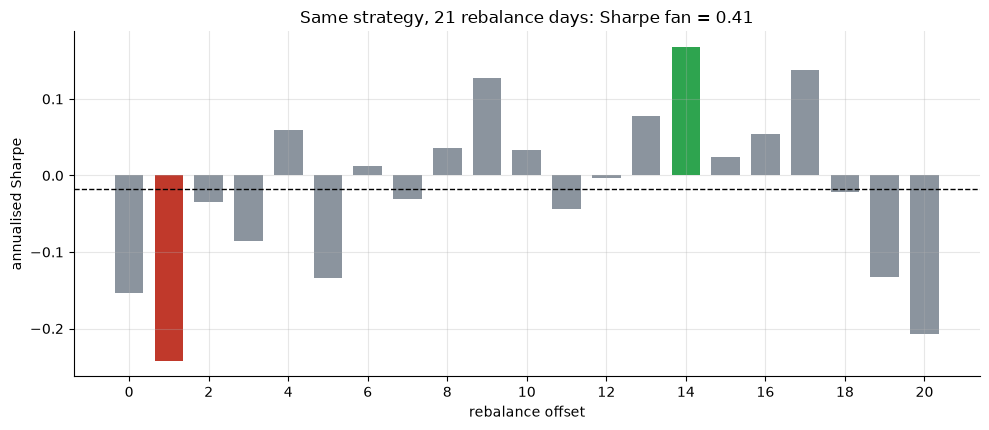

best #14 +0.168 | worst #1 -0.242 | spread 0.410 | sd 0.111 | mean -0.017 | n=2453


In [3]:
tl = st.timing_luck(RET, PERIOD, LOOKBACK, TOP_FRAC)
sh = tl['sharpes']
fig, ax = plt.subplots(figsize=(10, 4.4))
colors = [GREEN if i==tl['best_offset'] else RED if i==tl['worst_offset'] else GREY for i in range(len(sh))]
ax.bar(np.arange(len(sh)), sh, color=colors, width=.72)
ax.axhline(tl['sharpe_mean'], ls='--', c='k', lw=1)
ax.set_xlabel('rebalance offset'); ax.set_ylabel('annualised Sharpe'); ax.set_xticks(range(0,21,2))
ax.set_title('Same strategy, 21 rebalance days: Sharpe fan = %.2f' % tl['sharpe_spread'])
plt.tight_layout(); plt.show()
print('best #%d %+.3f | worst #%d %+.3f | spread %.3f | sd %.3f | mean %+.3f | n=%d'
      % (tl['best_offset'], tl['sharpe_best'], tl['worst_offset'], tl['sharpe_worst'],
         tl['sharpe_spread'], tl['sharpe_sd'], tl['sharpe_mean'], tl['n_days']))

> 💡 In plain words: **H₁ confirmed.** The identical rule spans -0.24 … +0.17 — a **0.41-Sharpe** gap (sd 0.11) driven purely by the rebalance day. The offsets average -0.02: there is no edge, only dispersion.

### 4b · Luck, not skill — the offset ranking does not persist (H₂)

Rank offsets by Sharpe in the first half vs the second half. A 45° line would mean the lucky offset is forecastable; a shapeless cloud means it's a coin-flip.

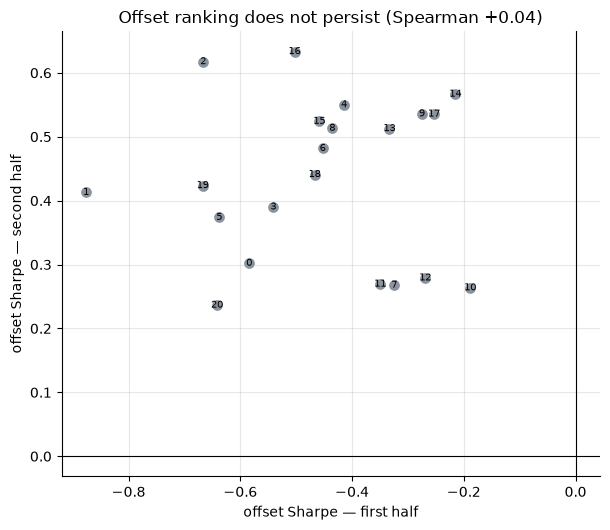

rank corr first-half vs second-half: +0.044


In [4]:
pr = st.offset_persistence(RET, PERIOD, LOOKBACK, TOP_FRAC)
fig, ax = plt.subplots(figsize=(6.2, 5.4))
ax.scatter(pr['sharpe_h1'], pr['sharpe_h2'], c=GREY, s=45, zorder=3)
for i,(a,b) in enumerate(zip(pr['sharpe_h1'], pr['sharpe_h2'])):
    ax.annotate(str(i), (a,b), fontsize=7, ha='center', va='center')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('offset Sharpe — first half'); ax.set_ylabel('offset Sharpe — second half')
ax.set_title('Offset ranking does not persist (Spearman %+.2f)' % pr['rank_corr'])
plt.tight_layout(); plt.show()
print('rank corr first-half vs second-half: %+.3f' % pr['rank_corr'])

> 💡 In plain words: **H₂ confirmed.** Rank correlation **+0.04** ≈ 0 — the offset that won early is unrelated to the one that wins late. The dispersion carries **zero forecastable information**: it is luck, definitionally.

### 4c · The fix — tranching collapses the dispersion (H₃)

Average all 21 offset books into one overlapping portfolio and read its Newey-West *t*.

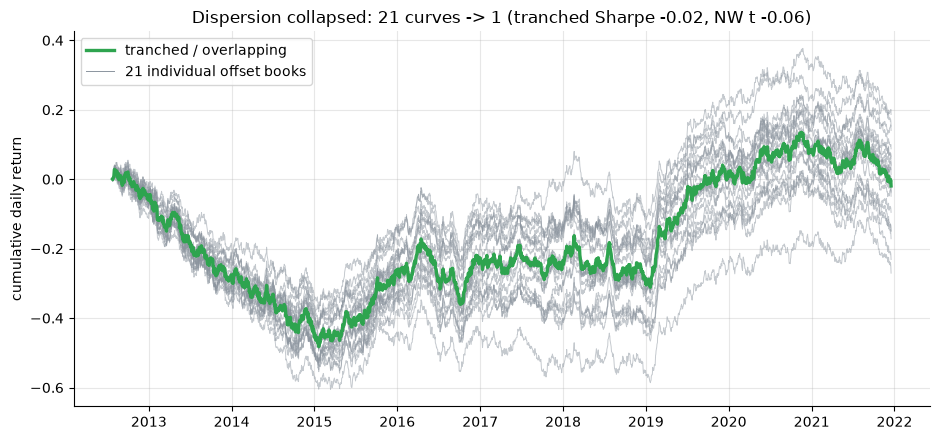

tranched: Sharpe -0.019 | mean -0.079 bps/day | NW(10) t -0.06 | one-sample t -0.06 | n=2453


In [5]:
tr = st.tranched_portfolio(RET, PERIOD, LOOKBACK, TOP_FRAC)
start = tr['start']; idx = RET.index[start:]
mom = st.trailing_return(RET.to_numpy(), LOOKBACK)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
for off in range(PERIOD):
    port, _ = st.offset_portfolio(RET.to_numpy(), mom, off, PERIOD, TOP_FRAC, 6)
    ax.plot(idx, np.cumsum(port[start:]), c=GREY, lw=.7, alpha=.5)
ax.plot(idx, np.cumsum(tr['seg']), c=GREEN, lw=2.4, label='tranched / overlapping')
ax.plot([], [], c=GREY, lw=.7, label='21 individual offset books')
ax.set_ylabel('cumulative daily return'); ax.legend()
ax.set_title('Dispersion collapsed: 21 curves -> 1 (tranched Sharpe %+.2f, NW t %+.2f)' % (tr['sharpe'], tr['t_nw']))
plt.tight_layout(); plt.show()
print('tranched: Sharpe %+.3f | mean %+.3f bps/day | NW(10) t %+.2f | one-sample t %+.2f | n=%d'
      % (tr['sharpe'], tr['mean_bps'], tr['t_nw'], tr['t_1s'], tr['n_days']))

> 💡 In plain words: **H₃ confirmed.** One curve, no dispersion, tranched NW *t* = **-0.06** — the phantom is gone and, correctly, no edge remains on the null tape.

### 4d · The cost of the tranched book

The tranched book trades a slice every day. Charge it and read the net.

In [6]:
for cb in (1.0, 5.0):
    tm = st.timer_stats(RET, PERIOD, LOOKBACK, TOP_FRAC, cost_bps=cb, borrow_bps_yr=50.0)
    print('cost=%.1f bps/side: gross %+.3f -> net %+.3f bps/day (cost %.3f/day, Sharpe net %+.3f, t %+.2f)'
          % (cb, tm['gross_bps'], tm['net_bps'], tm['cost_bps_per_day'], tm['sharpe_net'], tm['t_net']))

cost=1.0 bps/side: gross -0.079 -> net -0.406 bps/day (cost 0.327/day, Sharpe net -0.097, t -0.30)
cost=5.0 bps/side: gross -0.079 -> net -1.168 bps/day (cost 1.089/day, Sharpe net -0.278, t -0.87)


> 💡 In plain words: flat gross (-0.08 bps/day), negative net (-0.41 at 1 bp, -1.17 at 5 bps). Nothing to harvest — `MIRAGE`.

## 5 · The verdict

- **Signal `NONE`** — a 0.41-Sharpe phantom fan with rank-corr +0.04 and a dispersion-free tranched NW *t* of -0.06; synthetic-only, so never `REAL`.
- **Tradability `MIRAGE`** — unforecastable winner; tranched null book nets -0.41 bps/day at 1 bp.
- **Does rebalance timing break inference? `CONFIRMED`** — ~0.44-Sharpe artefact (25-seed mean), collapsed by tranching.

## 6 · Could you trade it? — the honest read

You cannot trade an unforecastable dispersion; picking the best offset in hindsight is curve-fitting and won't repeat. The tranched book is the only defensible construction, and on a no-edge tape it earns nothing net of costs. The point of the study is *not* a strategy — it's a warning that a backtest's Sharpe is contaminated by an arbitrary calendar choice unless you tranch it away.

## 7 · Going further — the synthetic positive control (25 seeds)

Is the tranched book just numb to everything, or does it reward a **real** edge? Plant a genuine momentum premium (`mom_edge > 0`) and check: the tranched book must light up, while the timing-luck dispersion stays present (it's an artefact of *when*, not *what*). Averaged over seeds so no lucky seed can fake it — live below on a few seeds, with the frozen 25-seed numbers from `docs/results.md`.

live (6 seeds):
  NULL   : phantom spread 0.402 | rank corr -0.024 | tranched Sharpe -0.213 (NW t -0.685) | fires 0/6
  PLANTED: phantom spread 0.451 | rank corr -0.001 | tranched Sharpe +1.168 (NW t +3.563) | fires 5/6

frozen (25 seeds, docs/results.md):
  NULL   : spread 0.442 | rank corr -0.088 | tranched Sharpe -0.047 (NW t -0.147) | fires 0/25
  PLANTED: spread 0.447 | rank corr +0.003 | tranched Sharpe +1.387 (NW t +4.244) | fires 24/25


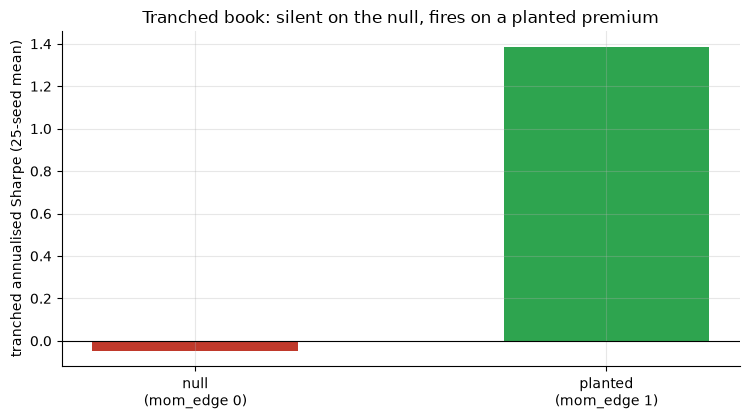

In [7]:
lo = st.seed_robust(data, mom_edge=0.0, n_seeds=6)
hi = st.seed_robust(data, mom_edge=1.0, n_seeds=6)
print('live (6 seeds):')
print('  NULL   : phantom spread %.3f | rank corr %+.3f | tranched Sharpe %+.3f (NW t %+.3f) | fires %d/6'
      % (lo['mean_sharpe_spread'], lo['mean_rank_corr'], lo['mean_tranched_sharpe'], lo['mean_tranched_t_nw'], lo['tranched_t_fires']))
print('  PLANTED: phantom spread %.3f | rank corr %+.3f | tranched Sharpe %+.3f (NW t %+.3f) | fires %d/6'
      % (hi['mean_sharpe_spread'], hi['mean_rank_corr'], hi['mean_tranched_sharpe'], hi['mean_tranched_t_nw'], hi['tranched_t_fires']))
print()
print('frozen (25 seeds, docs/results.md):')
print('  NULL   : spread %.3f | rank corr %+.3f | tranched Sharpe %+.3f (NW t %+.3f) | fires %d/25'
      % (R['null25_spread'], R['null25_corr'], R['null25_tsh'], R['null25_tnw'], R['null25_fires']))
print('  PLANTED: spread %.3f | rank corr %+.3f | tranched Sharpe %+.3f (NW t %+.3f) | fires %d/25'
      % (R['edge25_spread'], R['edge25_corr'], R['edge25_tsh'], R['edge25_tnw'], R['edge25_fires']))
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['null\n(mom_edge 0)','planted\n(mom_edge 1)'], [R['null25_tsh'], R['edge25_tsh']],
       color=[RED, GREEN], width=.5)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('tranched annualised Sharpe (25-seed mean)')
ax.set_title('Tranched book: silent on the null, fires on a planted premium')
plt.tight_layout(); plt.show()

The tranched book is **silent on the null** (25-seed Sharpe -0.05, NW *t* -0.15, fires 0/25) and **robustly positive when a real premium is planted** (+1.39, NW *t* +4.24, fires 24/25) — the machinery detects genuine edge and is not itself the artefact. Crucially the phantom dispersion is ~0.44 Sharpe units in **both** worlds: it is a property of *when* you rebalance, independent of whether there is anything to trade. For the other ways construction choices fake a Sharpe, see [344 Backtest-Overfitting](../../344-backtest-overfitting/) and [590 Sharpe-Hacking](../../590-sharpe-hacking/).